In [39]:
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('./data/pet_adoption_data.csv')

X = df.drop('AdoptionLikelihood', axis=1)
y = df['AdoptionLikelihood']
X.drop('PetID', axis=1, inplace=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
kategoryczne = ['PetType', 'Breed', 'Color', 'Size']

ciągłe = ["AgeMonths", "WeightKg", "AdoptionFee", "DaysInShelter"]

bin = ['Vaccinated', "HealthCondition", "PreviosOwner"]


In [103]:
from sklearn.metrics import make_scorer
import numpy as np

def shelter_score(y_true, y_prob, budget=200, cost=10):
    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]
    
    n_ads = budget // cost
    top_idx = y_prob.argsort()[-n_ads:]
    chosen_true = np.array(y_true)[top_idx]
    
    # E[adopcje] = suma oczekiwanych wartości dla każdego zwierzaka
    expected_adoptions = chosen_true.sum() * 0.70 + (n_ads - chosen_true.sum()) * 0.10
    return float(expected_adoptions)

scorer = make_scorer(shelter_score, response_method='predict_proba')

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import precision_score



preprocessor = ColumnTransformer([
    ('num', KBinsDiscretizer(encode='ordinal', quantile_method='averaged_inverted_cdf'), ["AgeMonths", "WeightKg", "AdoptionFee", "TimeInShelterDays"]),
    ('cat', OrdinalEncoder(), ['PetType', 'Breed', 'Color', 'Size']),
    ('bin', 'passthrough', ['Vaccinated', "HealthCondition", "PreviousOwner"])
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', CategoricalNB())
])

alpha = [0.001, 0.01, 0.05, 0.10, 0.20, 0.50, 1.0, 1.5]
# alpha = [x / 10 for  x in range(1, 11)]
#0.1, 0.2, ..., 1.0

n_bins = range(2, 11)
#2, 3, ..., 10

param_grid = {
    'prep__num__strategy': ['kmeans' ,'quantile'],
    'prep__num__n_bins': n_bins,
    'model__alpha': alpha
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring=scorer)
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print("Najlepszy wynik na zbiorze treningowym:", grid_search.best_score_)

model = grid_search.best_estimator_
y_pred = model.predict(X_test)

number = shelter_score(y_test, y_pred)
print(f"Liczba na zbiorze testowym: {number}")

Najlepsze parametry: {'model__alpha': 0.001, 'prep__num__n_bins': 2, 'prep__num__strategy': 'kmeans'}
Najlepszy wynik na zbiorze treningowym: 13.4
Liczba na zbiorze testowym: 11.6


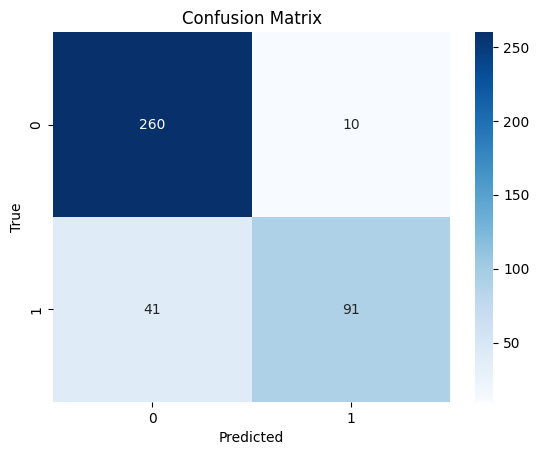

In [109]:

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt



cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()